In [1]:
# HealthGuard AI - Hypertension EDA
# Author: HealthGuard AI Team
# Date: 2026
# Purpose: Exploratory Data Analysis of Hypertension Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

plt.style.use('seaborn-v0_8')
sns.set_palette('Set2')

print("=" * 50)
print("   HealthGuard AI - Hypertension EDA")
print("=" * 50)
print("Libraries Loaded Successfully!")

   HealthGuard AI - Hypertension EDA
Libraries Loaded Successfully!


In [2]:
# Load Hypertension Dataset
# Source: Kaggle
# Records: 1985 patients, 11 columns

df = pd.read_csv("E:/HealthGuard_AI/data/raw/hypertension_dataset.csv")

print("Dataset Loaded Successfully!")
print("=" * 50)
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")
print("=" * 50)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nFirst 5 Rows:")
df.head()

Dataset Loaded Successfully!
Total Rows: 1985
Total Columns: 11

Column Names:
['Age', 'Salt_Intake', 'Stress_Score', 'BP_History', 'Sleep_Duration', 'BMI', 'Medication', 'Family_History', 'Exercise_Level', 'Smoking_Status', 'Has_Hypertension']

First 5 Rows:


,Age,Salt_Intake,Stress_Score,BP_History,Sleep_Duration,BMI,Medication,Family_History,Exercise_Level,Smoking_Status,Has_Hypertension
0,69,8.0,9,Normal,6.4,25.8,NaN,Yes,Low,Non-Smoker,Yes
1,32,11.7,10,Normal,5.4,23.4,NaN,No,Low,Non-Smoker,No
2,78,9.5,3,Normal,7.1,18.7,NaN,No,Moderate,Non-Smoker,No
3,38,10.0,10,Hypertension,4.2,22.1,ACE Inhibitor,No,Low,Non-Smoker,Yes
4,41,9.8,1,Prehypertension,5.8,16.2,Other,No,Moderate,Non-Smoker,No


In [3]:
# Basic Dataset Information

print("=" * 50)
print("DATASET INFORMATION")
print("=" * 50)
df.info()

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1985 entries, 0 to 1984
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1985 non-null   int64  
 1   Salt_Intake       1985 non-null   float64
 2   Stress_Score      1985 non-null   int64  
 3   BP_History        1985 non-null   object 
 4   Sleep_Duration    1985 non-null   float64
 5   BMI               1985 non-null   float64
 6   Medication        1186 non-null   object 
 7   Family_History    1985 non-null   object 
 8   Exercise_Level    1985 non-null   object 
 9   Smoking_Status    1985 non-null   object 
 10  Has_Hypertension  1985 non-null   object 
dtypes: float64(3), int64(2), object(6)
memory usage: 170.7+ KB


In [4]:
# Basic Statistical Analysis

print("=" * 50)
print("BASIC STATISTICS")
print("=" * 50)
df.describe().round(2)

BASIC STATISTICS


,Age,Salt_Intake,Stress_Score,Sleep_Duration,BMI
count,1985.00,1985.00,1985.00,1985.00,1985.00
mean,50.34,8.53,4.98,6.45,26.02
std,19.44,1.99,3.14,1.54,4.51
min,18.00,2.50,0.00,1.50,11.90
25%,34.00,7.20,2.00,5.40,23.00
50%,50.00,8.50,5.00,6.50,25.90
75%,67.00,9.90,8.00,7.50,29.10
max,84.00,16.40,10.00,11.40,41.90


In [5]:
# Check Missing Values

print("=" * 50)
print("MISSING VALUES CHECK")
print("=" * 50)

print("NaN Values:")
print(df.isnull().sum())

total_missing = df.isnull().sum().sum()
print(f"\nTotal Missing Values: {total_missing}")

if total_missing == 0:
    print("No Missing Values Found!")

MISSING VALUES CHECK
NaN Values:
Age                   0
Salt_Intake           0
Stress_Score          0
BP_History            0
Sleep_Duration        0
BMI                   0
Medication          799
Family_History        0
Exercise_Level        0
Smoking_Status        0
Has_Hypertension      0
dtype: int64

Total Missing Values: 799


In [6]:
# Check Duplicate Rows

print("=" * 50)
print("DUPLICATE CHECK")
print("=" * 50)

duplicates = df.duplicated().sum()
print(f"Total Duplicate Rows: {duplicates}")

if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Duplicates Removed!")
    print(f"New Shape: {df.shape}")
else:
    print("No Duplicates Found!")

DUPLICATE CHECK
Total Duplicate Rows: 0
No Duplicates Found!


TARGET DISTRIBUTION
Hypertension Distribution:
Has_Hypertension
Yes    1032
No      953
Name: count, dtype: int64


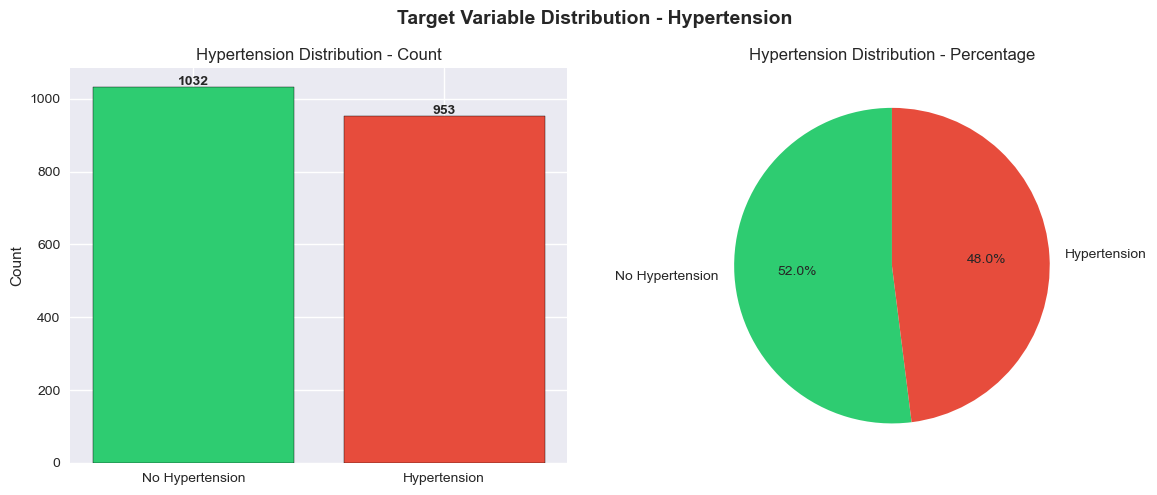

In [7]:
# Target Variable Distribution

print("=" * 50)
print("TARGET DISTRIBUTION")
print("=" * 50)

print("Hypertension Distribution:")
print(df['Has_Hypertension'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(['No Hypertension', 'Hypertension'],
            df['Has_Hypertension'].value_counts(),
            color=['#2ecc71', '#e74c3c'],
            edgecolor='black')
axes[0].set_title('Hypertension Distribution - Count')
axes[0].set_ylabel('Count')
for i, v in enumerate(df['Has_Hypertension'].value_counts()):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

axes[1].pie(df['Has_Hypertension'].value_counts(),
            labels=['No Hypertension', 'Hypertension'],
            autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'],
            startangle=90)
axes[1].set_title('Hypertension Distribution - Percentage')

plt.suptitle('Target Variable Distribution - Hypertension',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Categorical Columns:

BP_History:
BP_History
Normal             796
Prehypertension    620
Hypertension       569
Name: count, dtype: int64

Medication:
Medication
Beta Blocker     412
ACE Inhibitor    323
Diuretic         245
Other            206
Name: count, dtype: int64

Family_History:
Family_History
No     1000
Yes     985
Name: count, dtype: int64

Exercise_Level:
Exercise_Level
Low         936
Moderate    658
High        391
Name: count, dtype: int64

Smoking_Status:
Smoking_Status
Non-Smoker    1417
Smoker         568
Name: count, dtype: int64

Has_Hypertension:
Has_Hypertension
Yes    1032
No      953
Name: count, dtype: int64


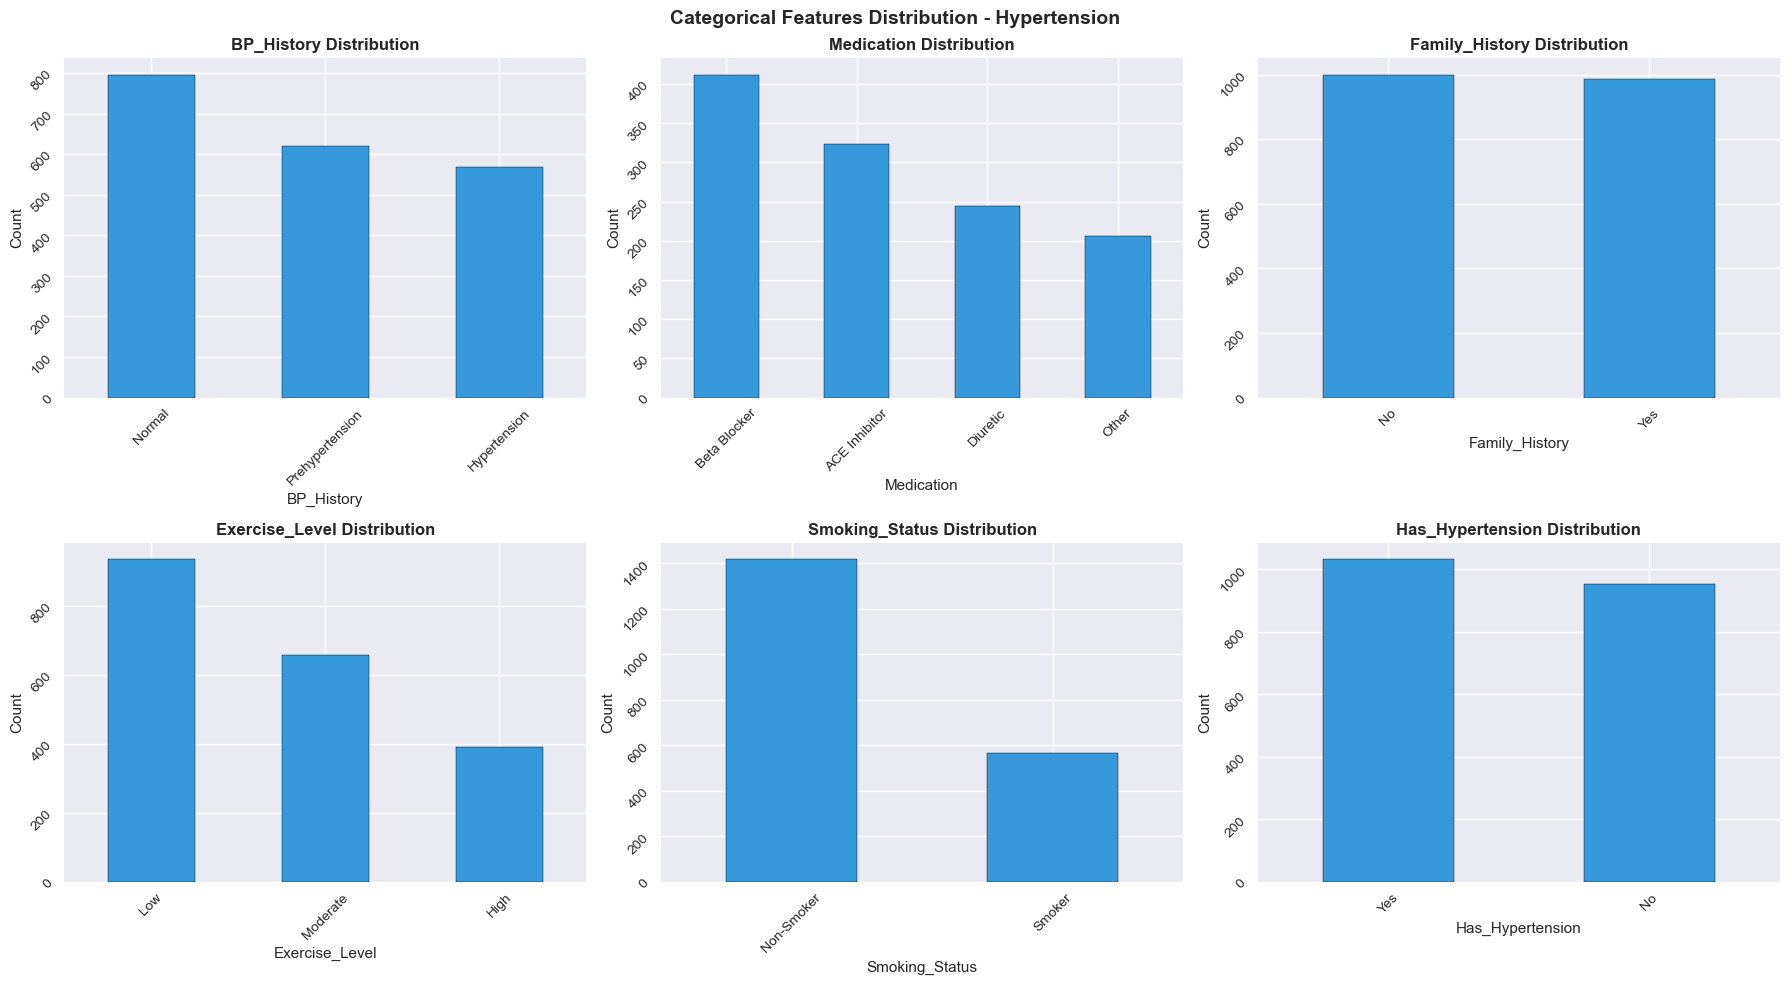

In [8]:
# Categorical Columns Analysis
# Check unique values in each categorical column

cat_cols = df.select_dtypes(include=['object']).columns
print("Categorical Columns:")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    print(f"\n{col}:")
    print(df[col].value_counts())

    df[col].value_counts().plot(kind='bar',
                                ax=axes[i],
                                color='#3498db',
                                edgecolor='black')
    axes[i].set_title(f'{col} Distribution', fontweight='bold')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(rotation=45)

for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical Features Distribution - Hypertension',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

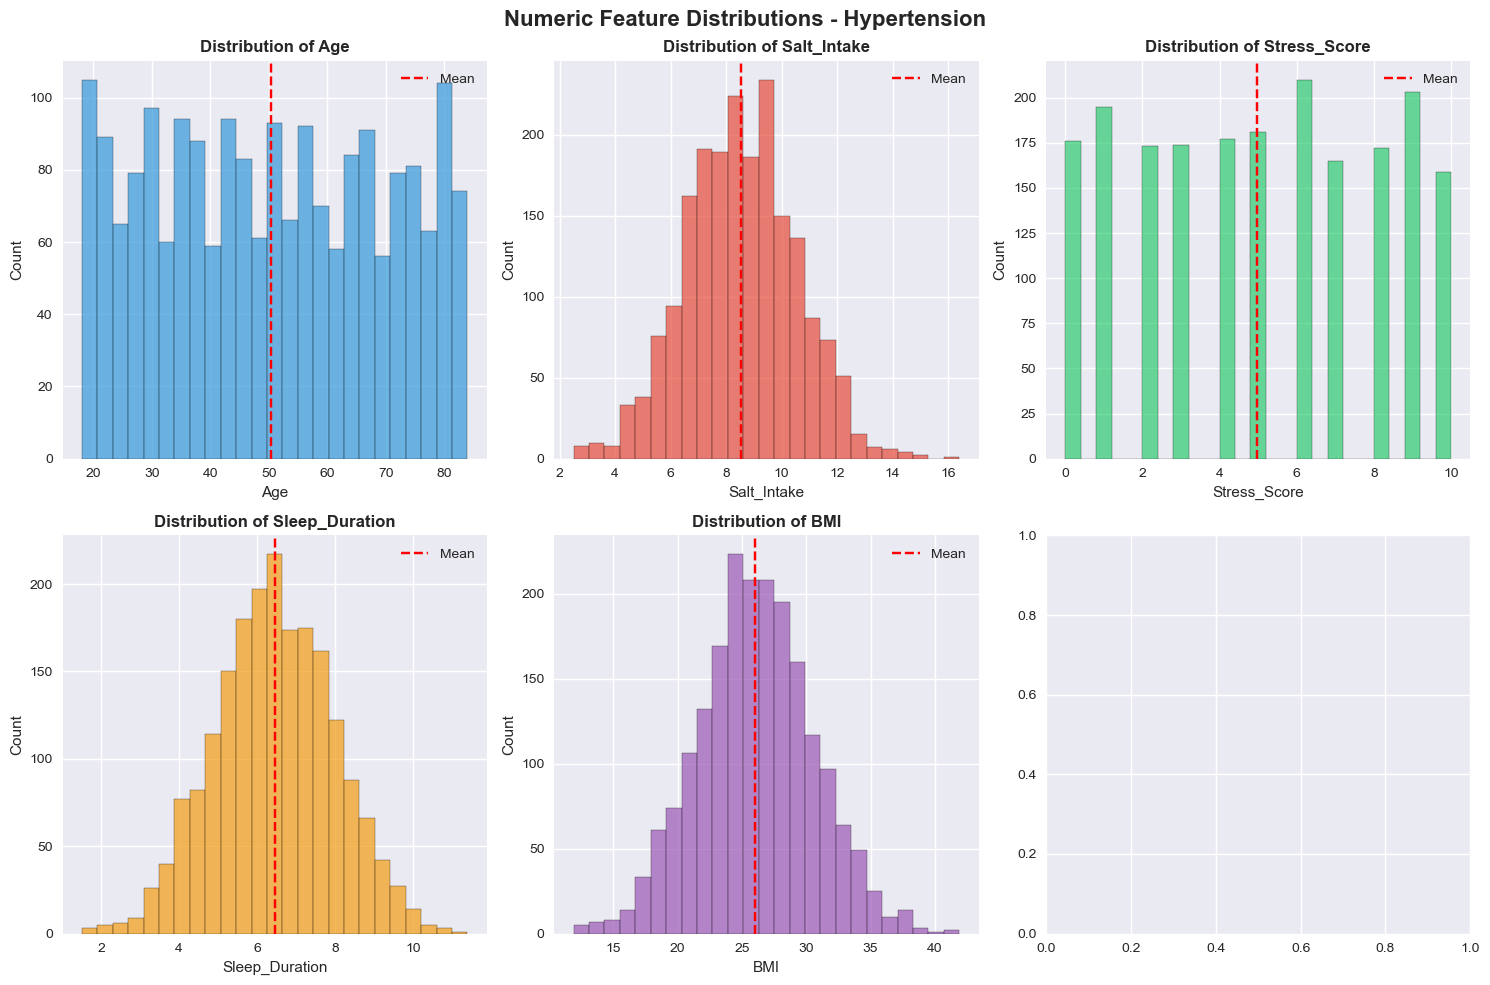

In [9]:
# Numeric Feature Distributions

numeric_cols = df.select_dtypes(
    include=['int64', 'float64']).columns

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

colors = ['#3498db', '#e74c3c', '#2ecc71',
          '#f39c12', '#9b59b6', '#1abc9c']

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=25,
                 color=colors[i],
                 edgecolor='black',
                 alpha=0.7)
    axes[i].set_title(f'Distribution of {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].axvline(df[col].mean(), color='red',
                    linestyle='--', label='Mean')
    axes[i].legend()

plt.suptitle('Numeric Feature Distributions - Hypertension',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

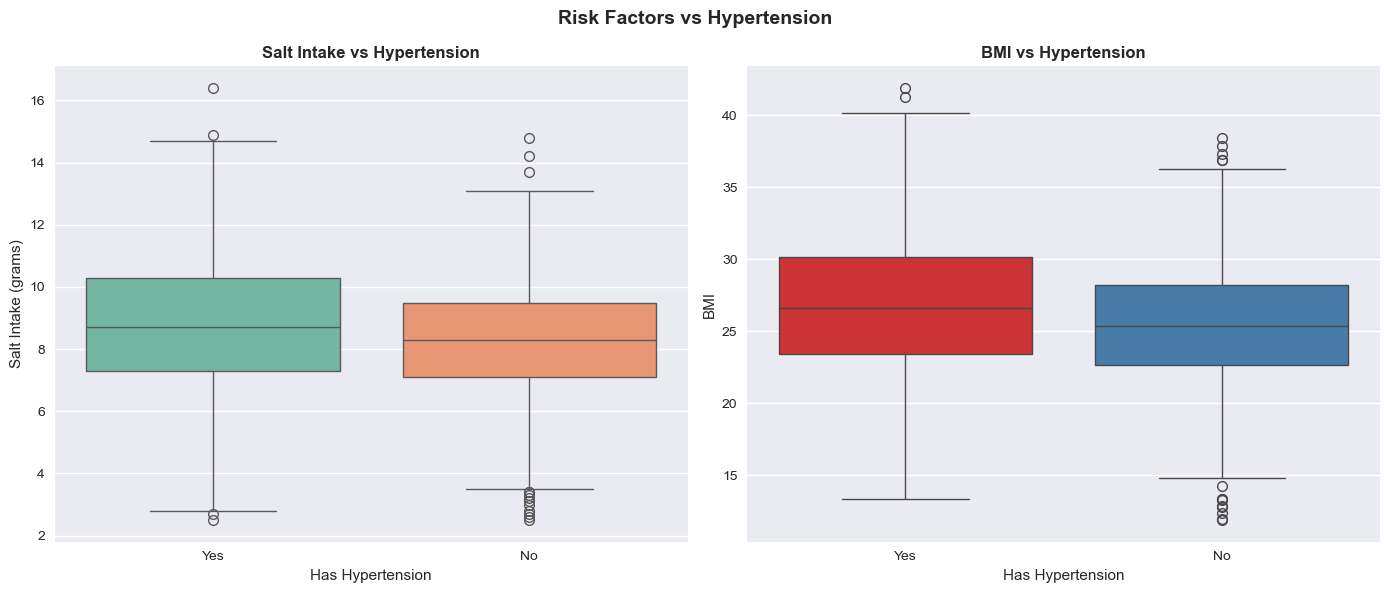

Higher Salt & BMI = More Hypertension Risk!


In [10]:
# Salt Intake and BMI vs Hypertension

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(x='Has_Hypertension', y='Salt_Intake',
            data=df, ax=axes[0],
            hue='Has_Hypertension',
            palette='Set2', legend=False)
axes[0].set_title('Salt Intake vs Hypertension',
                  fontweight='bold')
axes[0].set_xlabel('Has Hypertension')
axes[0].set_ylabel('Salt Intake (grams)')

sns.boxplot(x='Has_Hypertension', y='BMI',
            data=df, ax=axes[1],
            hue='Has_Hypertension',
            palette='Set1', legend=False)
axes[1].set_title('BMI vs Hypertension', fontweight='bold')
axes[1].set_xlabel('Has Hypertension')
axes[1].set_ylabel('BMI')

plt.suptitle('Risk Factors vs Hypertension',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Higher Salt & BMI = More Hypertension Risk!")

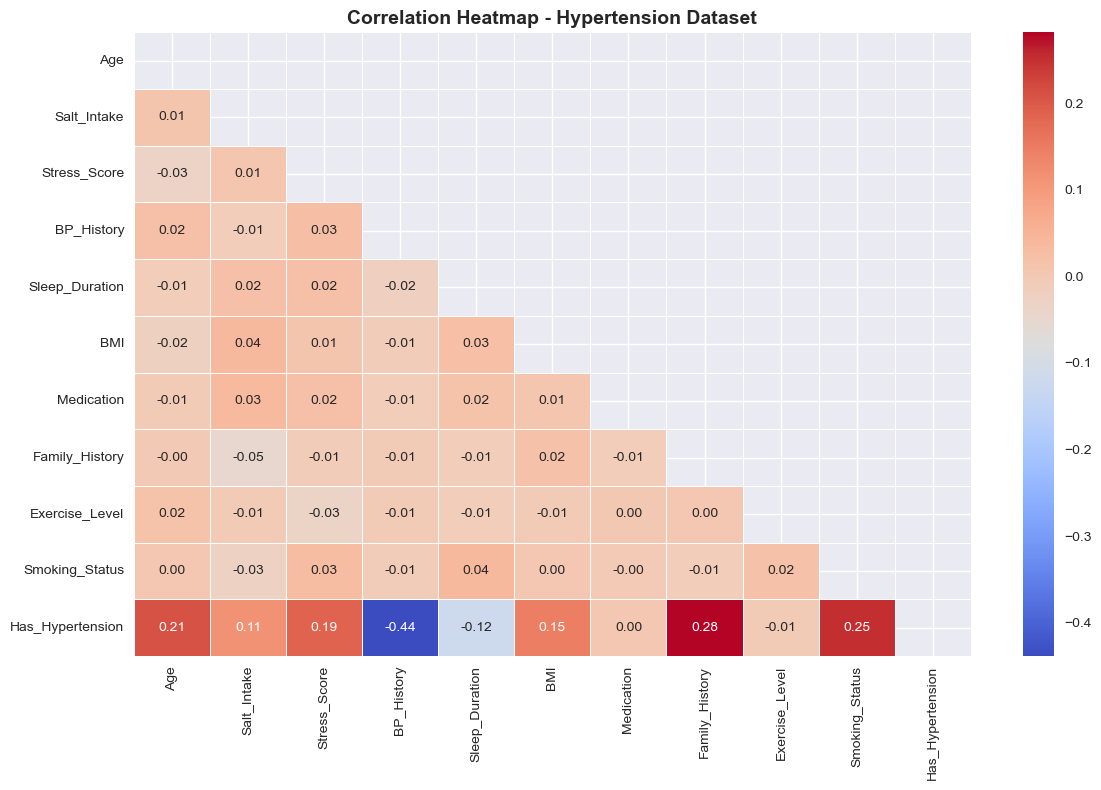

Top Correlations with Hypertension:
Has_Hypertension    1.000000
Family_History      0.282144
Smoking_Status      0.251437
Age                 0.210677
Stress_Score        0.186910
BMI                 0.145093
Salt_Intake         0.114415
Medication          0.003981
Exercise_Level     -0.006794
Sleep_Duration     -0.119561
BP_History         -0.438679
Name: Has_Hypertension, dtype: float64


In [11]:
# Correlation Heatmap (Numeric Only)

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df_encoded = df.copy()
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df_encoded[col] = le.fit_transform(df[col].astype(str))

plt.figure(figsize=(12, 8))
correlation = df_encoded.corr(numeric_only=True)

mask = np.triu(np.ones_like(correlation, dtype=bool))

sns.heatmap(correlation,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            linewidths=0.5,
            mask=mask)

plt.title('Correlation Heatmap - Hypertension Dataset',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Top Correlations with Hypertension:")
print(correlation['Has_Hypertension'].sort_values(ascending=False))

In [15]:
print("=" * 60)
print("   HYPERTENSION EDA - SUMMARY REPORT")
print("=" * 60)

print(f"\nDataset Shape: {df.shape}")
print(f"Total Patients: {len(df)}")
print(f"Hypertension: {(df['Has_Hypertension']=='Yes').sum()}")
print(f"No Hypertension: {(df['Has_Hypertension']=='No').sum()}")

print("\nKEY FINDINGS:")
print("-" * 40)
print("1. Salt intake is major risk factor")
print("2. BMI strongly related to hypertension")
print("3. Age increases hypertension risk")
print("4. Stress level affects blood pressure")
print("5. Family history is important predictor")

print("\nNEXT STEPS:")
print("-" * 40)
print("1. Data Cleaning")
print("2. Encode Categorical Variables")
print("3. Model Training")

print("\nHypertension EDA Complete!")
print("=" * 60)

   HYPERTENSION EDA - SUMMARY REPORT

Dataset Shape: (1985, 11)
Total Patients: 1985
Hypertension: 1032
No Hypertension: 953

KEY FINDINGS:
----------------------------------------
1. Salt intake is major risk factor
2. BMI strongly related to hypertension
3. Age increases hypertension risk
4. Stress level affects blood pressure
5. Family history is important predictor

NEXT STEPS:
----------------------------------------
1. Data Cleaning
2. Encode Categorical Variables
3. Model Training

Hypertension EDA Complete!
